In [11]:
from DELCgen import *
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

Read 313 lines of data


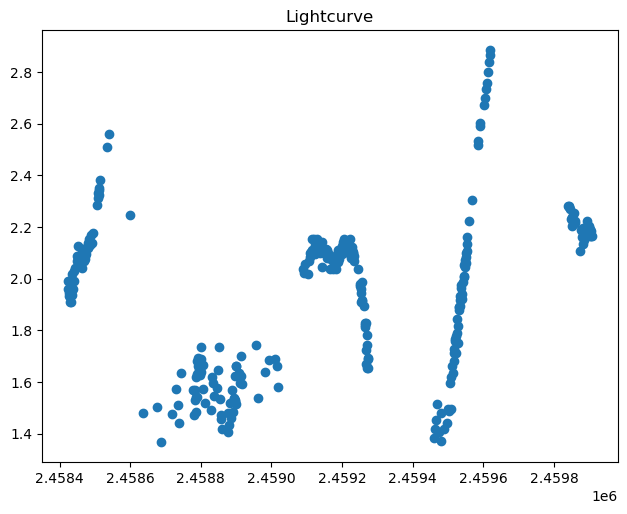

In [12]:
#------- Input parameters -------
from DELCgen import *
import scipy.stats as st

# File Route
fileroute = "C:/Users/jacek/CORONA/DELightcurveSimulation-master/data (2).txt"
datfile = "data (2).txt"

# Bending power law params
A,v_bend,a_low,a_high,c = 0.03, 2.3e-4, 1.1, 2.2, 0 
# Probability density function params
kappa,theta,lnmu,lnsig,weight = 5.67, 5.96, 2.14, 0.31,0.82
# Simulation params
RedNoiseL,RandomSeed,aliasTbin, tbin = 100,12,1,100 

#--------- Commands ---------------
# load data lightcurve
datalc = Load_Lightcurve(fileroute, tbin)
print(datalc)
# plot the data lightcurve and its PDF and PSD
datalc.Plot_Lightcurve()

In [15]:
# estimate underlying variance od data light curve
datalc.STD_Estimate()


# simulate artificial light curve with Emmanoulopoulos method, using the PSD and PDF of the data
delc = datalc.Simulate_DE_Lightcurve() # defaults to bending PL and mix of gamma and lognormal dist.

# simulate artificial light curve with Timmer & Koenig method
tklc = Simulate_TK_Lightcurve(datalc,BendingPL, (A,v_bend,a_low,a_high,c),
                                RedNoiseL,aliasTbin,RandomSeed)

# simulate artificial light curve with Emmanoulopoulos method, scipy distribution
delc2 = Simulate_DE_Lightcurve(datalc,BendingPL, (A,v_bend,a_low,a_high,c),
                                ([st.gamma,st.lognorm],[[kappa,0, theta],\
                                    [lnsig,0, np.exp(lnmu)]],[weight,1-weight]))

# simulate artificial light curve with Emmanoulopoulos method, custom distribution
delc3 = Simulate_DE_Lightcurve(datalc,BendingPL, (A,v_bend,a_low,a_high,c),
                                ([[Gamma,LogNormal],[[kappa, theta],\
                                  [lnmu, lnsig]],[weight,1-weight]]),MixtureDist)                                

# plot lightcurves and their PSDs ands PDFs for comparison
Comparison_Plots([datalc,tklc,delc])

Fitting PSD for standard deviation estimation...


C:\Users\jacek\CORONA\DELightcurveSimulation-master\DELCgen.py:236: RuntimeWarning: divide by zero encountered in power
  numer = v**-a_low
C:\Users\jacek\CORONA\DELightcurveSimulation-master\DELCgen.py:395: RuntimeWarning: invalid value encountered in scalar multiply
  p_nq = np.log(np.pi * periodogram[1][-1]*psd[-1]) \
C:\Users\jacek\CORONA\DELightcurveSimulation-master\DELCgen.py:237: RuntimeWarning: divide by zero encountered in power
  denom = 1 + (v/v_bend)**(a_high-a_low)
C:\Users\jacek\CORONA\DELightcurveSimulation-master\DELCgen.py:238: RuntimeWarning: invalid value encountered in divide
  out = A * (numer/denom) + c
C:\Users\jacek\CORONA\DELightcurveSimulation-master\DELCgen.py:394: RuntimeWarning: invalid value encountered in log
  p = 2.0 * np.sum( np.log(psd[:-1]) + (periodogram[1][:-1]/psd[:-1]) )
C:\Users\jacek\CORONA\DELightcurveSimulation-master\DELCgen.py:395: RuntimeWarning: divide by zero encountered in log
  p_nq = np.log(np.pi * periodogram[1][-1]*psd[-1]) \


PDF not fitted, fitting using defaults (gamma + lognorm)
#### FIT FAILED ####
Fit parameters not assigned.
Try different initial parameters with the 'initial_params' keyword argument
Simulation terminated due to failed fit(s)


NameError: name 'fileroute' is not defined